Multibeam mesh

Reads the `geolocated.xyz` exported from Neptus. `bathymetry.xyz` was also trialed, but doesnt contain vehicle depth, so the following depth correction would be more involved.

Not sure if the geolocated contains DVL + MBES or how this works, but looks sensible

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvista as pv
from pyproj import Transformer
from scipy.spatial import Delaunay
import rasterio
from rasterio.transform import from_origin
from scipy.stats import binned_statistic_2d
from rasterio.fill import fillnodata
from scipy.ndimage import distance_transform_edt

In [3]:
RAW_POINT_FILE = Path("data/raw/geolocated.xyz")

SOURCE_CRS = "EPSG:4326"
TARGET_CRS = "EPSG:32633"

MIN_DEPTH_M = 35.0
MAX_DEPTH_M = 70.0
MAX_MESH_POINTS = 200_000
MAX_TRIANGLE_EDGE_M = 10.0
VERTICAL_EXAGGERATION = 2.0
RANDOM_SEED = 42
GEOTIFF_RESOLUTION_M = 0.5


It seems that the exported neptus 'depth' values are depth to seabed + 2x vehicle depth for whatever reason?

So we use a corrected seabed depth of `z - depth`.

In [119]:
required_columns = {"t", "lon", "lat", "depth", "z"}
raw = pd.read_csv(RAW_POINT_FILE)

raw = raw.replace([np.inf, -np.inf], np.nan).dropna(subset=sorted(required_columns)).copy()

raw["time"] = pd.to_datetime(raw["t"], unit="ms", utc=True)
raw["seabed_depth"] = raw["z"] - raw["depth"]

print(f"loaded points: {len(raw):,}")
print("vehicle-depth range:", raw["depth"].min(), raw["depth"].max())
print("corrected seabed range:", raw["seabed_depth"].min(), raw["seabed_depth"].max())

loaded points: 4,372,338
vehicle-depth range: -1.0 51.49
corrected seabed range: 4.5169999999999995 88.779


Filter outliers using a depth interval found in the reduced Neptus point cloud.

In [120]:

coordinate_mask = (
    raw["lon"].between(-180, 180)
    & raw["lat"].between(-90, 90)
)
depth_mask = raw["seabed_depth"].between(
    MIN_DEPTH_M,
    MAX_DEPTH_M,
)

print(f"points outside coordinate bounds: {(~coordinate_mask).sum():,}")
print(f"points outside depth bounds: {(~depth_mask).sum():,}")

points = (
    raw.loc[coordinate_mask & depth_mask, ["lon", "lat", "seabed_depth"]]
    .rename(columns={"seabed_depth": "depth"})
)

print(f"retained points: {len(points):,}")
print(points["depth"].describe())

points outside coordinate bounds: 0
points outside depth bounds: 2,465
retained points: 4,369,873
count    4.369873e+06
mean     5.081022e+01
std      6.212729e+00
min      3.666900e+01
25%      4.584700e+01
50%      5.106900e+01
75%      5.533700e+01
max      6.870600e+01
Name: depth, dtype: float64


project the point locations to UTM 33N

In [121]:
transformer = Transformer.from_crs(
    SOURCE_CRS,
    TARGET_CRS,
    always_xy=True,
)

points["easting"], points["northing"] = transformer.transform(
    points["lon"].to_numpy(),
    points["lat"].to_numpy(),
)

east_west_extent = points["easting"].max() - points["easting"].min()
north_south_extent = points["northing"].max() - points["northing"].min()

print(f"east-west extent: {east_west_extent:.1f} m")
print(f"north-south extent: {north_south_extent:.1f} m")

east-west extent: 343.4 m
north-south extent: 267.8 m


Reject points too far off of median of 1x1m grid:

In [122]:
LOCAL_CELL_SIZE_M = 1.0
MAX_LOCAL_DEPTH_DIFFERENCE_M = 5.0

cell_x = np.floor(
    points["easting"] / LOCAL_CELL_SIZE_M
).astype(np.int64)

cell_y = np.floor(
    points["northing"] / LOCAL_CELL_SIZE_M
).astype(np.int64)

local_median = points["depth"].groupby(
    [cell_x, cell_y]
).transform("median")

local_difference = np.abs(
    points["depth"] - local_median
)

keep = local_difference <= MAX_LOCAL_DEPTH_DIFFERENCE_M

print("locally rejected points:", (~keep).sum())
print(
    "largest local difference:",
    f"{local_difference.max():.2f} m",
)

points = points.loc[keep]

locally rejected points: 1391
largest local difference: 15.08 m


Subsample points to not draw 4M:

In [123]:
if len(points) > MAX_MESH_POINTS:
    display_points = points.sample(
        MAX_MESH_POINTS,
        random_state=RANDOM_SEED,
    )
else:
    display_points = points

Plot location vs depth:

displayed points: 200,000
displayed depth range: 36.86800000000001 68.029


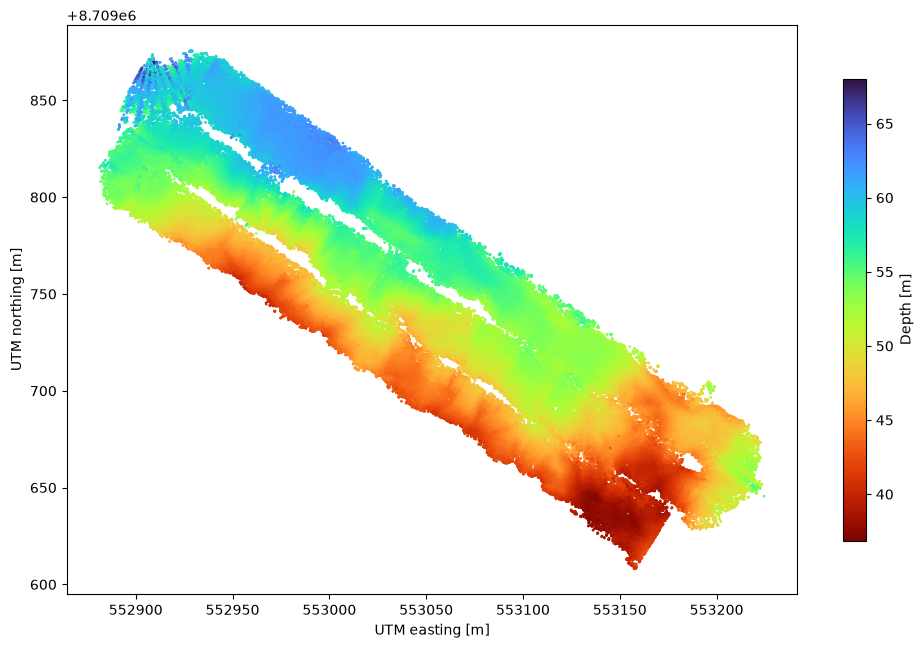

In [ ]:


print(f"displayed points: {len(display_points):,}")
print("displayed depth range:", display_points["depth"].min(), display_points["depth"].max())

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    display_points["easting"],
    display_points["northing"],
    c=display_points["depth"],
    s=1,
    cmap="turbo_r",
)

ax.set_aspect("equal")
ax.set_xlabel("UTM easting [m]")
ax.set_ylabel("UTM northing [m]")
# ax.set_title("Multibeam coverage and corrected seabed depth")

colorbar = fig.colorbar(scatter, ax=ax, shrink=0.6)
colorbar.set_label("Depth [m]")

plt.tight_layout()
plt.savefig("data/output/bathy_col.png", dpi=300, bbox_inches="tight")
plt.show()

To compare, just the subsampled pointcloud in neptus:

Neptus points: 93,172
Neptus depth range: 37.1578 84.4983
Neptus point-data arrays: ['colorsZ']


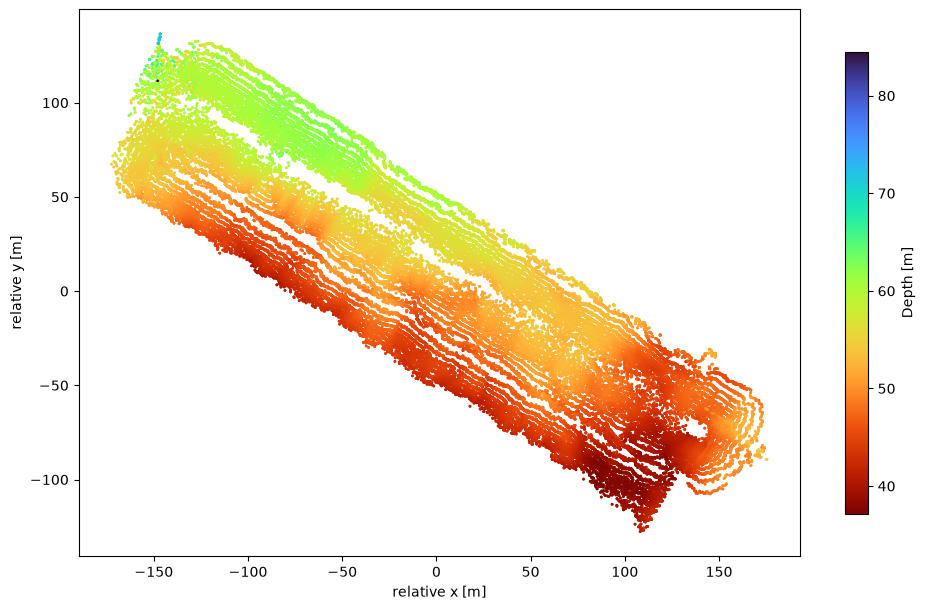

In [10]:
NEPTUS_POINT_FILE = Path("data/raw/neptus_multibeam.vtk")


neptus_cloud = pv.read(NEPTUS_POINT_FILE)
neptus_xyz = np.asarray(neptus_cloud.points)
neptus_depth = neptus_xyz[:, 2]

plot_xy = neptus_xyz[:, :2].copy()
plot_xy -= np.median(plot_xy, axis=0)

# change either sign if the result is mirrored
plot_xy[:, 0] *= -1
# plot_xy[:, 1] *= -1

# determine the current long-axis direction
covariance = np.cov(plot_xy.T)
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
main_axis = eigenvectors[:, np.argmax(eigenvalues)]

current_angle = np.arctan2(
    main_axis[1],
    main_axis[0],
)

target_angle = np.deg2rad(-32)

angle = target_angle - current_angle

rotation_matrix = np.array(
    [
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle), np.cos(angle)],
    ]
)

plot_xy = plot_xy @ rotation_matrix.T

print(f"Neptus points: {neptus_cloud.n_points:,}")
print("Neptus depth range:", neptus_depth.min(), neptus_depth.max())
print("Neptus point-data arrays:", list(neptus_cloud.point_data.keys()))

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    plot_xy[:, 0],
    plot_xy[:, 1],
    c=neptus_depth,
    s=1,
    cmap="turbo_r",
)

ax.set_aspect("equal")
ax.set_xlabel("relative x [m]")
ax.set_ylabel("relative y [m]")
# ax.set_title("Multibeam coverage and corrected seabed depth")

colorbar = fig.colorbar(scatter, ax=ax, shrink=0.6)
colorbar.set_label("Depth [m]")

plt.tight_layout()
plt.savefig("data/output/bathy_neptus.png", dpi=300, bbox_inches="tight")
plt.show()


Plot simple Mesh combining points up to `MAX_TRIANGLE_EDGE_M` distance.

In [126]:

# calculate mesh
easting_origin = display_points["easting"].mean()
northing_origin = display_points["northing"].mean()
depth_origin = display_points["depth"].median()

x = display_points["easting"].to_numpy() - easting_origin
y = display_points["northing"].to_numpy() - northing_origin
depth = display_points["depth"].to_numpy()
xy = np.column_stack((x, y))

triangles = Delaunay(xy, qhull_options="QJ").simplices
triangle_xy = xy[triangles]

edge_lengths = np.stack((
    np.linalg.norm(triangle_xy[:, 0] - triangle_xy[:, 1], axis=1),
    np.linalg.norm(triangle_xy[:, 1] - triangle_xy[:, 2], axis=1),
    np.linalg.norm(triangle_xy[:, 2] - triangle_xy[:, 0], axis=1),
))

triangles = triangles[edge_lengths.max(axis=0) <= MAX_TRIANGLE_EDGE_M]
print(f"retained triangles: {len(triangles):,}")

z = -(depth - depth_origin) * VERTICAL_EXAGGERATION
mesh_points = np.column_stack((x, y, z))
mesh_faces = np.column_stack((
    np.full(len(triangles), 3, dtype=np.int64),
    triangles,
)).ravel()

display_mesh = pv.PolyData(mesh_points, mesh_faces)
display_mesh["depth_m"] = depth


retained triangles: 399,784


/tmp/ipykernel_6252/2445087109.py:52: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  plotter.show(screenshot="data/output/bathy_3d.png")


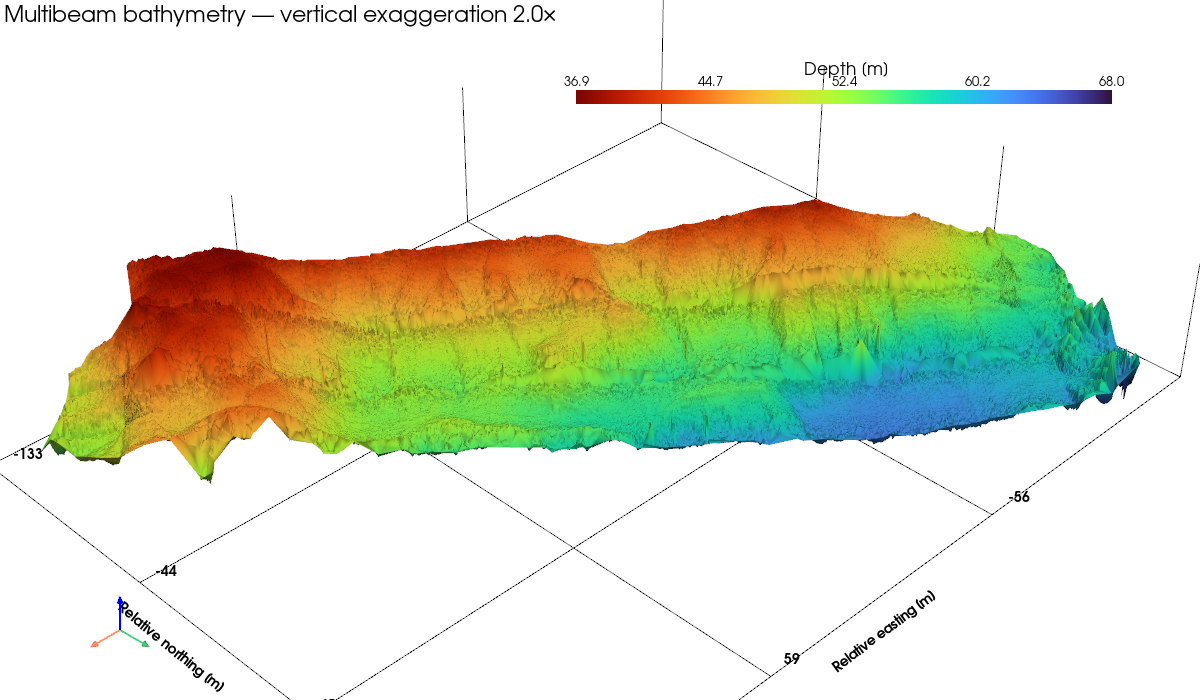

In [132]:
plotter = pv.Plotter(window_size=(1200, 700))
plotter.set_background("white")

plotter.add_mesh(
    display_mesh,
    scalars="depth_m",
    cmap="turbo_r",
    smooth_shading=True,
    scalar_bar_args={
        "title": "Depth [m]",
        "vertical": False,
        "position_x": 0.48,
        "position_y": 0.85,
        "width": 0.45,
        "height": 0.055,
        "title_font_size": 17,
        "label_font_size": 13,
        "fmt": "%.1f",
    },
)

plotter.show_bounds(
    grid="back",
    location="outer",
    xtitle="Relative easting [m]",
    ytitle="Relative northing [m]",
    ztitle=f"Relative elevation [m] ({VERTICAL_EXAGGERATION}×)",
    n_xlabels=4,
    n_ylabels=4,
    n_zlabels=4,
    font_size=14,
    fmt="%.0f",
    use_2d=True,
)

plotter.add_axes(
    line_width=2,
    labels_off=True,
)

plotter.add_text(
    f"Multibeam bathymetry — vertical exaggeration {VERTICAL_EXAGGERATION}×",
    position="upper_left",
    font_size=13,
    color="black",
)

plotter.view_isometric()
plotter.reset_camera()
plotter.camera.zoom(1.8)

plotter.show(screenshot="data/output/bathy_3d.png")

Now create mesh with higher point sample, export as geotiff.

In [128]:

RASTER_RESOLUTION_M = 0.5
NODATA_VALUE = -9999.0

x_edges = np.arange(
    np.floor(points["easting"].min() / RASTER_RESOLUTION_M)
    * RASTER_RESOLUTION_M,
    np.ceil(points["easting"].max() / RASTER_RESOLUTION_M)
    * RASTER_RESOLUTION_M
    + RASTER_RESOLUTION_M,
    RASTER_RESOLUTION_M,
)

y_edges = np.arange(
    np.floor(points["northing"].min() / RASTER_RESOLUTION_M)
    * RASTER_RESOLUTION_M,
    np.ceil(points["northing"].max() / RASTER_RESOLUTION_M)
    * RASTER_RESOLUTION_M
    + RASTER_RESOLUTION_M,
    RASTER_RESOLUTION_M,
)

depth_grid, _, _, _ = binned_statistic_2d(
    points["easting"],
    points["northing"],
    points["depth"],
    statistic="median",
    bins=[x_edges, y_edges],
)

print("raster size:", depth_grid.shape)
print("empty cells:", np.isnan(depth_grid).sum())

OUTPUT_DIR = Path("data/processed")

GEOTIFF_FILE = OUTPUT_DIR / "bathymetry_elevation_filled2_utm33n.tif"

# convert the grid to raster orientation and negative elevation
raster_elevation = (
    -depth_grid.T[::-1, :]
).astype(np.float32)

valid = np.isfinite(raster_elevation)

# interpolate across empty raster cells
filled_elevation = fillnodata(
    raster_elevation,
    mask=valid.astype(np.uint8),
    max_search_distance=max(raster_elevation.shape),
    smoothing_iterations=1,
)

# fill anything remaining with its nearest valid elevation
remaining = ~np.isfinite(filled_elevation)

if remaining.any():
    nearest_indices = distance_transform_edt(
        remaining,
        return_distances=False,
        return_indices=True,
    )

    filled_elevation[remaining] = filled_elevation[
        tuple(nearest_indices[:, remaining])
    ]

print("remaining empty cells:", np.isnan(filled_elevation).sum())
print(
    "elevation range:",
    filled_elevation.min(),
    filled_elevation.max(),
)

transform = from_origin(
    x_edges[0],
    y_edges[-1],
    RASTER_RESOLUTION_M,
    RASTER_RESOLUTION_M,
)

with rasterio.open(
    GEOTIFF_FILE,
    "w",
    driver="GTiff",
    height=filled_elevation.shape[0],
    width=filled_elevation.shape[1],
    count=1,
    dtype="float32",
    crs=TARGET_CRS,
    transform=transform,
    compress="deflate",
    predictor=3,
) as destination:
    destination.write(filled_elevation, 1)
    destination.set_band_description(
        1,
        "Filled seabed elevation [m]",
    )

print("saved:", GEOTIFF_FILE)


raster size: (688, 537)
empty cells: 256086
remaining empty cells: 0
elevation range: -67.658 -36.895
saved: data/processed/bathymetry_elevation_filled2_utm33n.tif
